# Childhood PSA analysis ? ages 1?15

This notebook displays the report. Reusable calculations and plotting logic live under `app.notebook.psa`; the same report facade can be used for another horizon.


In [1]:
from IPython.display import HTML, Markdown, display
import matplotlib.pyplot as plt

from app.notebook.psa import CHILDHOOD
from app.notebook.psa.presentation import render_table
from app.notebook.psa.report import PSAReport

report = PSAReport.load(CHILDHOOD)
print(f"{report.horizon.label}: {report.df.height:,} simulation rows")
print(f"WTP: {report.wtp:,.0f} IRR/QALY")

Childhood horizon (ages 1–15): 160,000 simulation rows
WTP: 18,000,000,000 IRR/QALY


In [2]:
sections = report.table_sections()
current_group = None
for section in sections:
    if section.group != current_group:
        display(Markdown(f"## {section.group}"))
        current_group = section.group
    if section.title != section.group:
        display(Markdown(f"### {section.title}"))
    display(HTML(render_table(section.data)))

## Calibration

### Expected and observed bleeding

time_horizon,sampling_method,regime,n_patients,expected_abr,realized_abr
childhood,bayesian,on-demand,"10,000",22.577,16.715
childhood,bayesian,prophylaxis,"10,000",3.871,3.682
childhood,dirichlet,on-demand,"10,000",22.263,20.018
childhood,dirichlet,prophylaxis,"10,000",3.826,3.658


### Uncertainty intervals

sampling_method,regime,expected_abr_ci_low,expected_abr_ci_high,realized_abr_ci_low,realized_abr_ci_high
bayesian,on-demand,22.262,22.892,19.771,20.269
bayesian,prophylaxis,3.839,3.902,3.892,3.970
dirichlet,on-demand,22.169,22.356,20.363,20.560
dirichlet,prophylaxis,3.795,3.857,3.878,3.958


...

comparison,paired_iterations,delta_cost,delta_cost_ci_low,delta_cost_ci_high
childhood prophylaxis bayesian vs childhood on-demand bayesian,"10,000","60,526,970,163.216","-17,912,338,179.719","116,083,825,333.269"
childhood prophylaxis bayesian is_discounting vs childhood on-demand bayesian is_discounting,"10,000","38,082,570,485.217","-10,867,486,395.440","71,507,302,099.783"
childhood prophylaxis bayesian ltb_absolute vs childhood on-demand bayesian ltb_absolute,"10,000","59,433,261,532.410","-17,994,673,952.435","105,114,314,506.664"
childhood prophylaxis bayesian weight_reduction_10 vs childhood on-demand bayesian weight_reduction_10,"10,000","53,990,926,030.288","-16,422,348,272.859","103,514,841,229.285"
childhood prophylaxis bayesian weight_reduction_20 vs childhood on-demand bayesian weight_reduction_20,"10,000","48,045,223,765.163","-13,426,039,608.642","91,803,199,717.049"
childhood prophylaxis bayesian weight_reduction_30 vs childhood on-demand bayesian weight_reduction_30,"10,000","41,959,145,008.412","-12,267,886,748.004","80,903,340,536.226"
childhood prophylaxis dirichlet vs childhood on-demand dirichlet,"10,000","59,022,709,719.987","-22,999,676,162.315","116,597,065,859.400"
childhood prophylaxis dirichlet ltb_absolute vs childhood on-demand dirichlet ltb_absolute,"10,000","58,670,361,952.220","2,844,729,175.373","96,724,624,755.711"


### Incremental QALYs

comparison,paired_iterations,delta_qaly,delta_qaly_ci_low,delta_qaly_ci_high
childhood prophylaxis bayesian vs childhood on-demand bayesian,"10,000",4.523,-8.640,12.456
childhood prophylaxis bayesian is_discounting vs childhood on-demand bayesian is_discounting,"10,000",3.147,-5.988,8.966
childhood prophylaxis bayesian ltb_absolute vs childhood on-demand bayesian ltb_absolute,"10,000",1.634,-3.417,4.954
childhood prophylaxis bayesian weight_reduction_10 vs childhood on-demand bayesian weight_reduction_10,"10,000",4.505,-8.388,12.462
childhood prophylaxis bayesian weight_reduction_20 vs childhood on-demand bayesian weight_reduction_20,"10,000",4.453,-8.775,12.408
childhood prophylaxis bayesian weight_reduction_30 vs childhood on-demand bayesian weight_reduction_30,"10,000",4.530,-8.400,12.492
childhood prophylaxis dirichlet vs childhood on-demand dirichlet,"10,000",5.083,-7.474,12.543
childhood prophylaxis dirichlet ltb_absolute vs childhood on-demand dirichlet ltb_absolute,"10,000",1.786,-3.132,3.762


### Cost-effectiveness decision

comparison,icer,interpretation,delta_nmb,probability_cost_effective
childhood prophylaxis bayesian vs childhood on-demand bayesian,"13,383,514,817.897",Cost-effective,"20,878,062,652.303",0.613
childhood prophylaxis bayesian is_discounting vs childhood on-demand bayesian is_discounting,"12,102,052,456.329",Cost-effective,"18,559,579,365.606",0.620
childhood prophylaxis bayesian ltb_absolute vs childhood on-demand bayesian ltb_absolute,"36,381,215,627.699",Not cost-effective,"-30,028,012,446.426",0.221
childhood prophylaxis bayesian weight_reduction_10 vs childhood on-demand bayesian weight_reduction_10,"11,984,240,032.250",Cost-effective,"27,101,964,793.821",0.631
childhood prophylaxis bayesian weight_reduction_20 vs childhood on-demand bayesian weight_reduction_20,"10,789,497,398.839",Cost-effective,"32,108,095,319.563",0.642
childhood prophylaxis bayesian weight_reduction_30 vs childhood on-demand bayesian weight_reduction_30,"9,263,249,677.285",Cost-effective,"39,574,294,817.077",0.665
childhood prophylaxis dirichlet vs childhood on-demand dirichlet,"11,611,190,431.899",Cost-effective,"32,475,985,542.218",0.673
childhood prophylaxis dirichlet ltb_absolute vs childhood on-demand dirichlet ltb_absolute,"32,855,927,147.832",Not cost-effective,"-26,528,017,881.749",0.146


## Abr Distribution

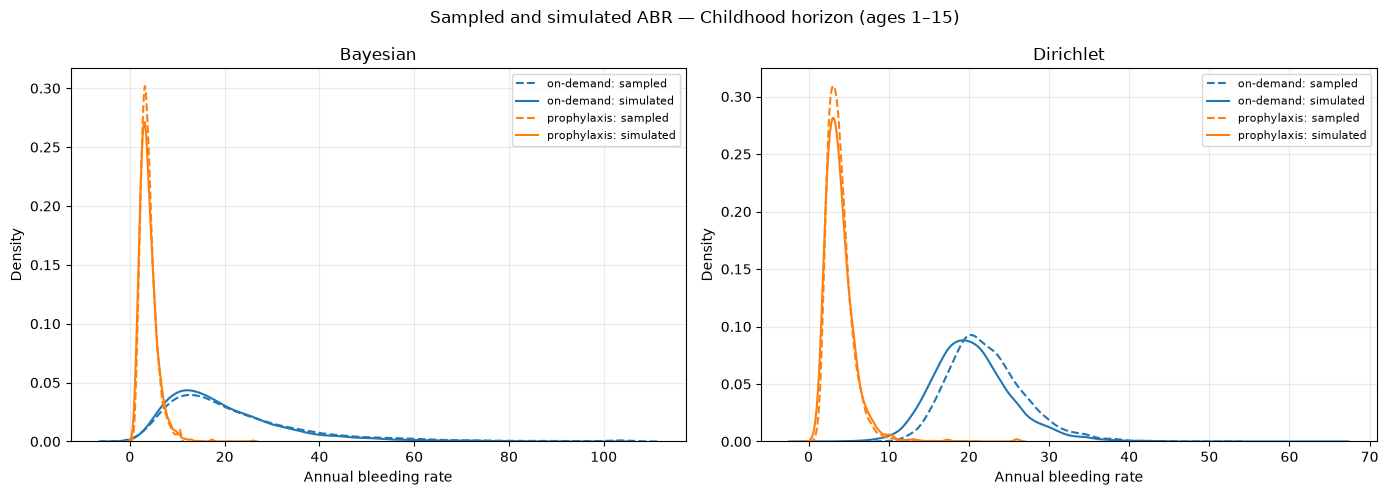

## Survival Curve

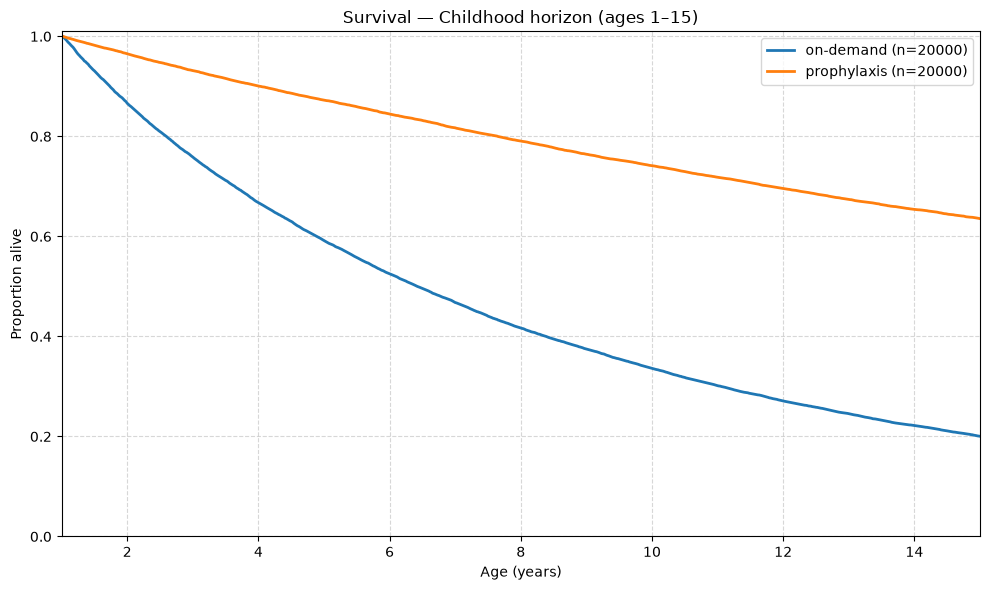

## Health State Distribution

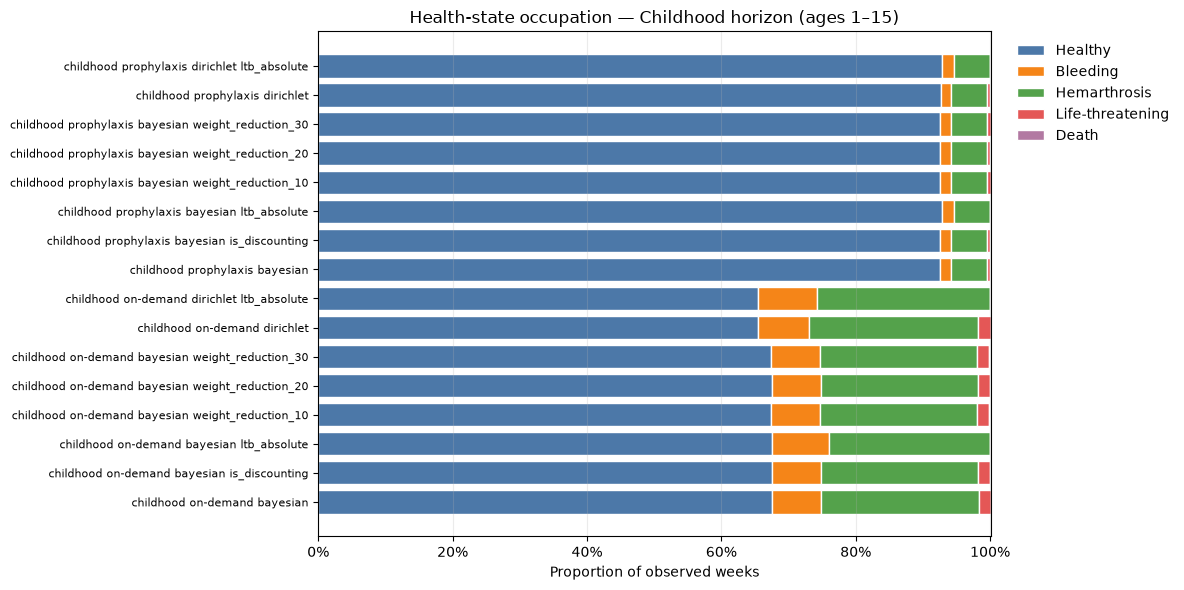

## Qaly Distribution

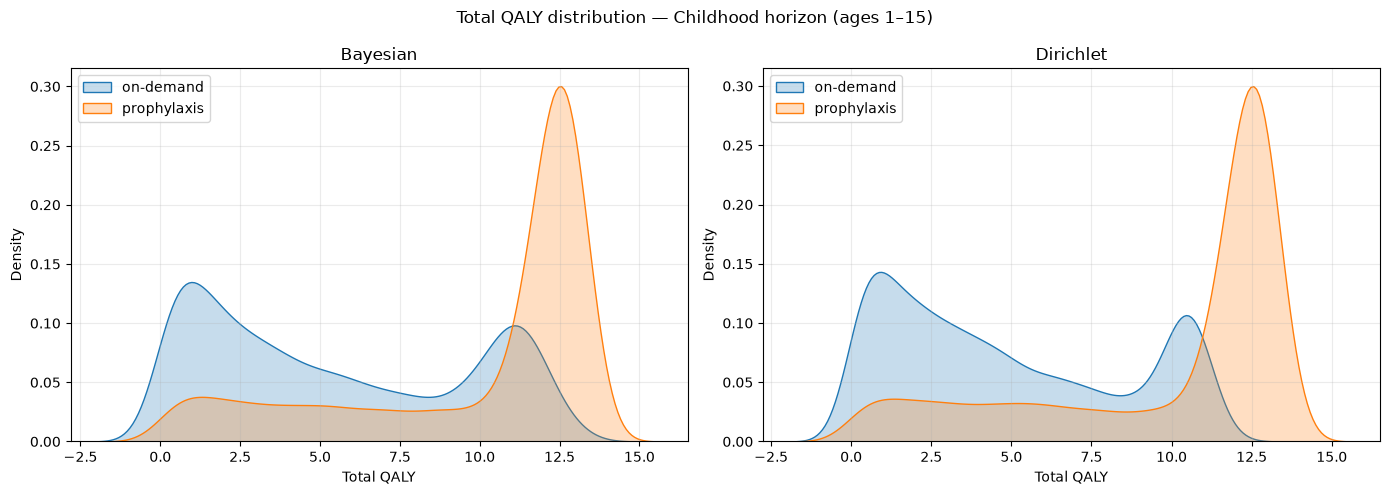

## Cost Distribution

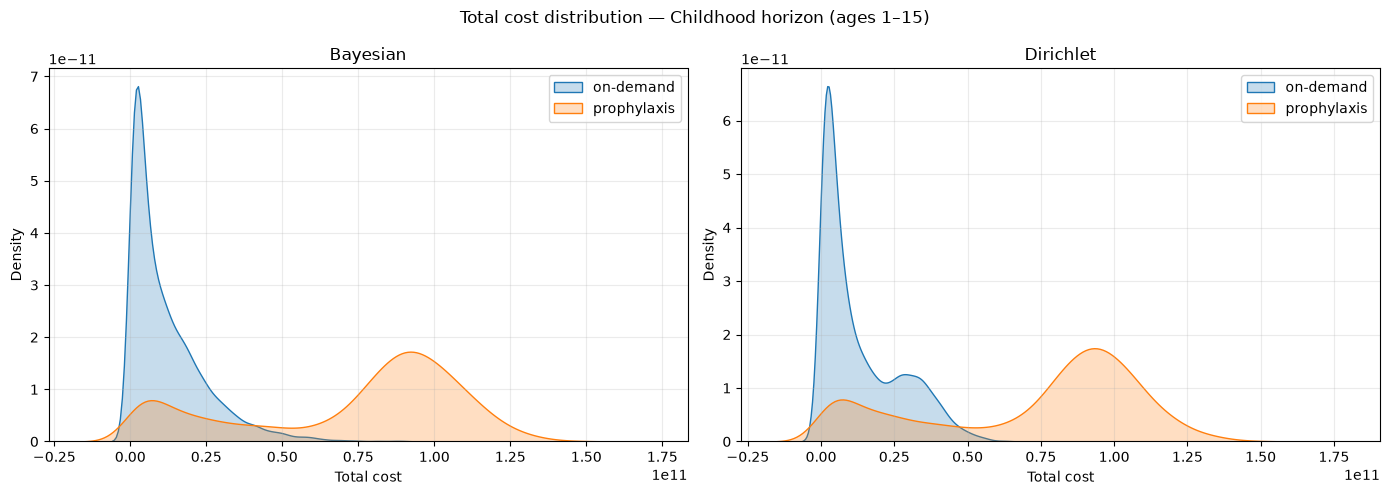

## Joint Cost Qaly

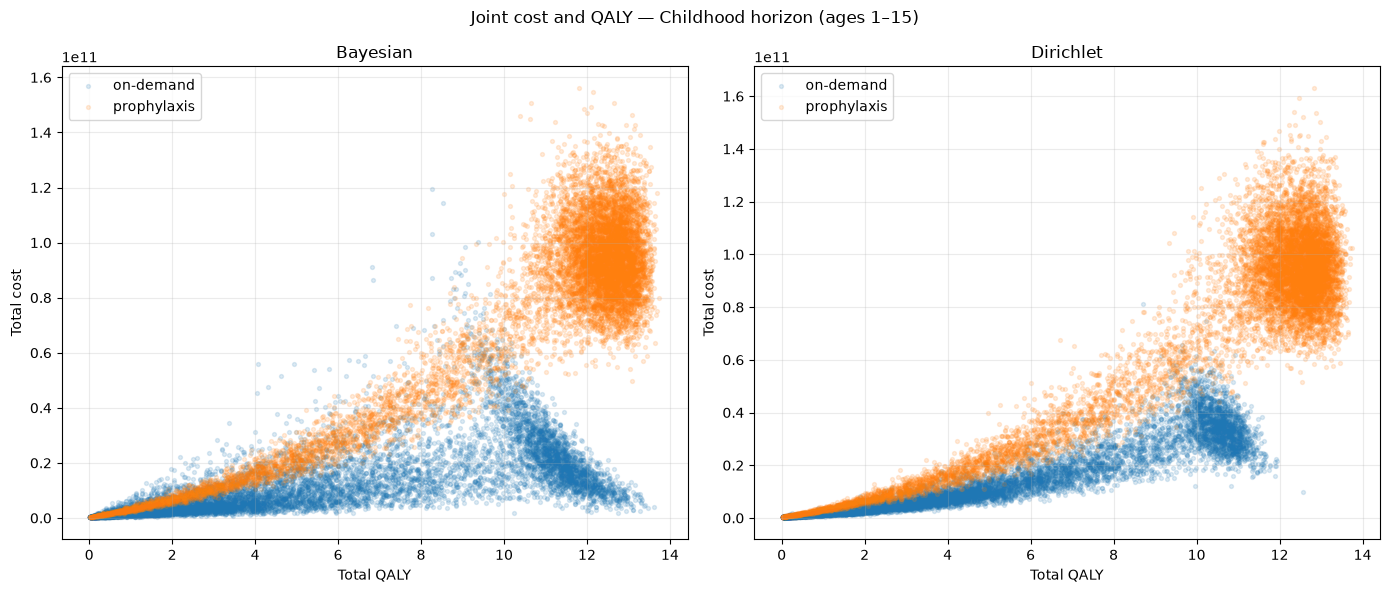

## Cost Effectiveness Planes

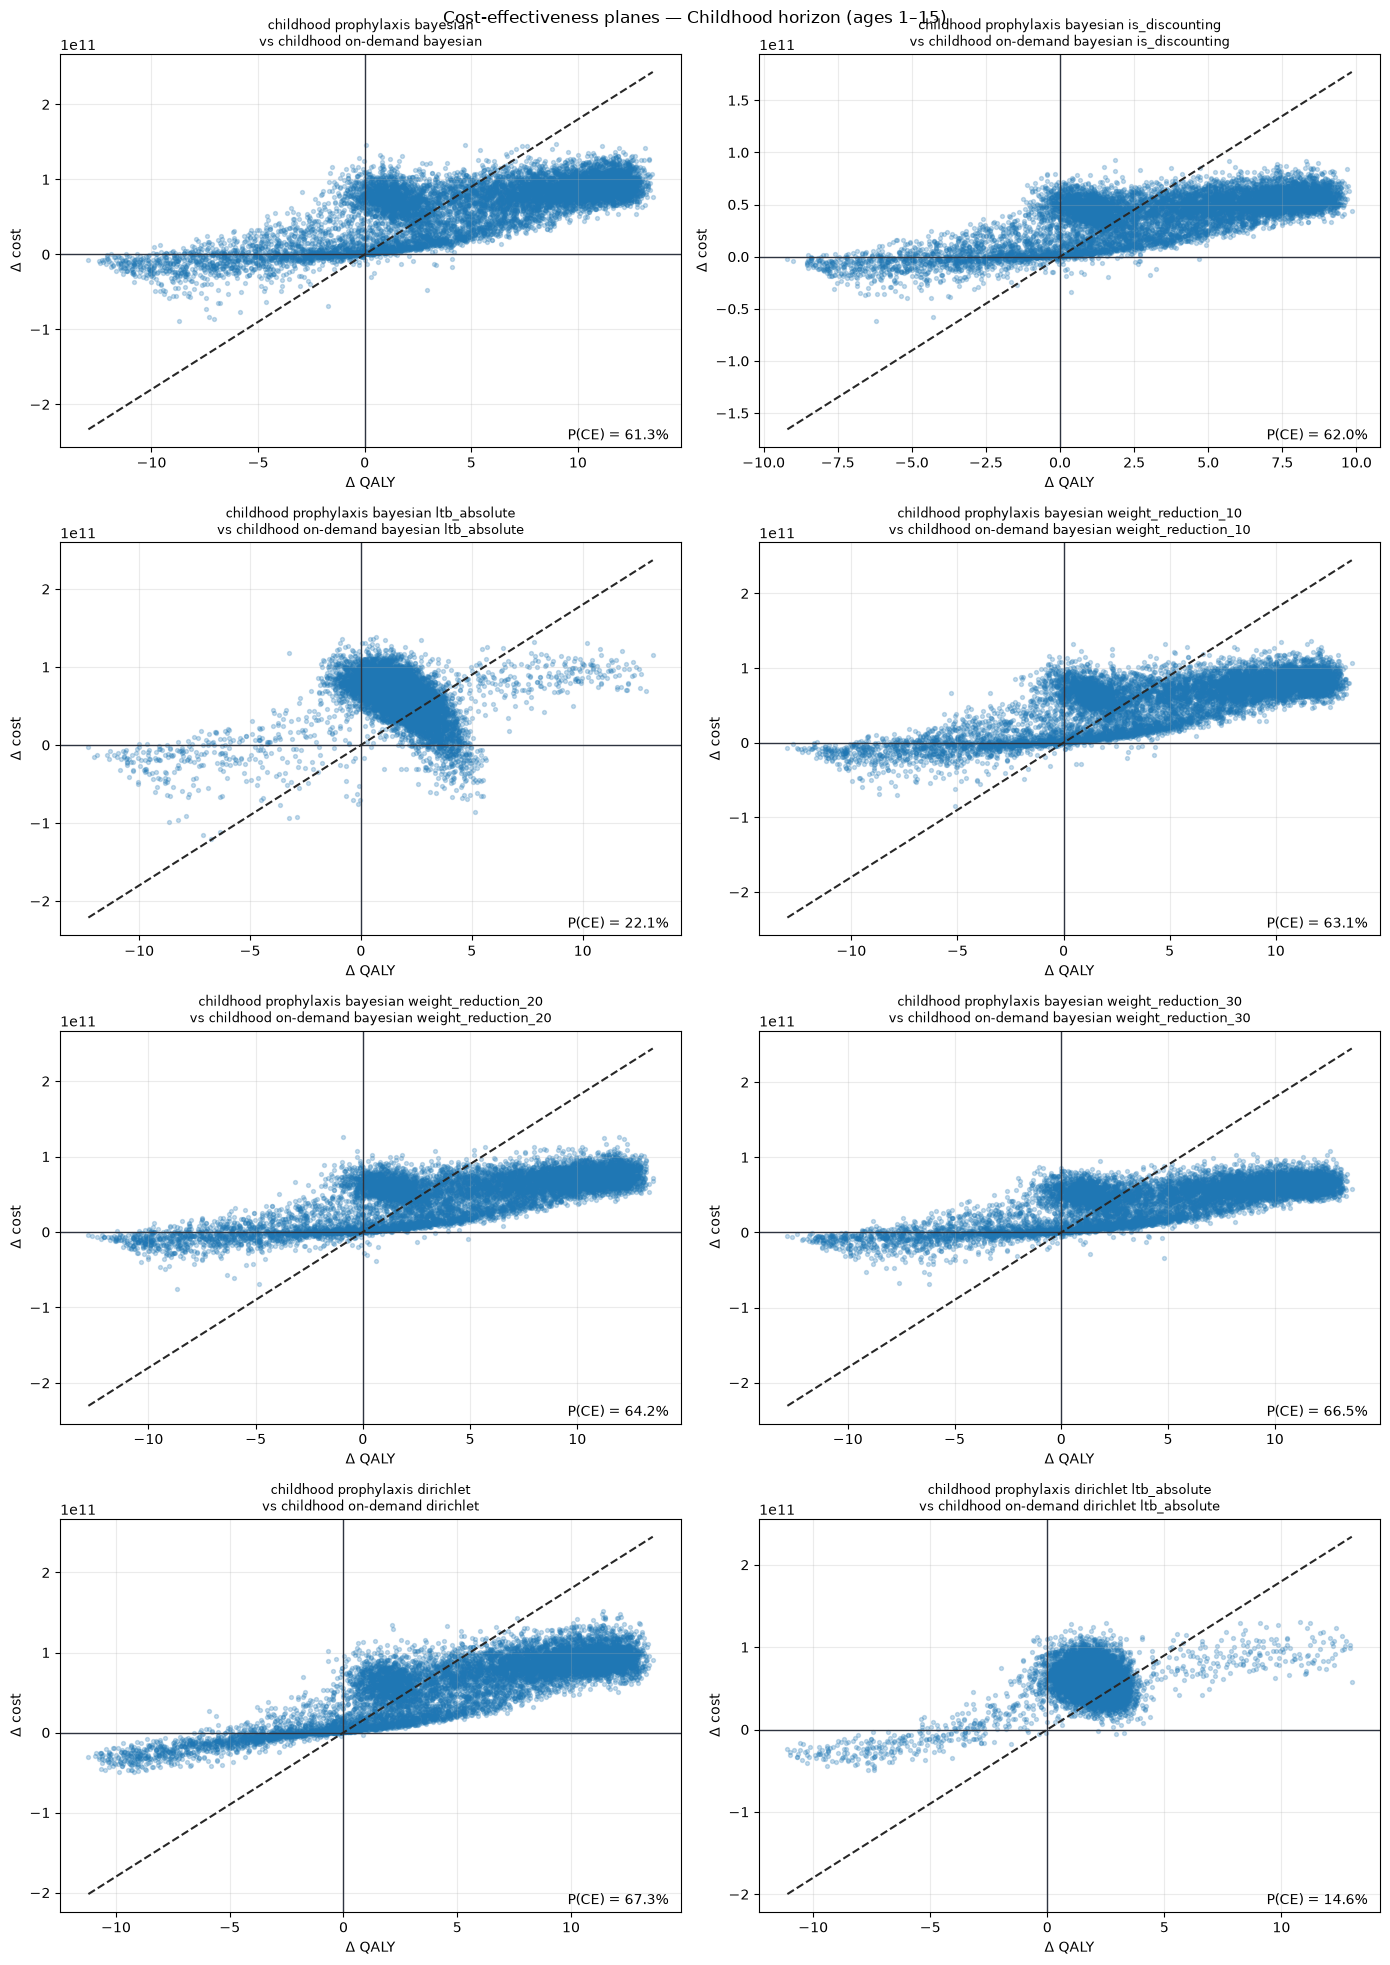

## Icer Distributions

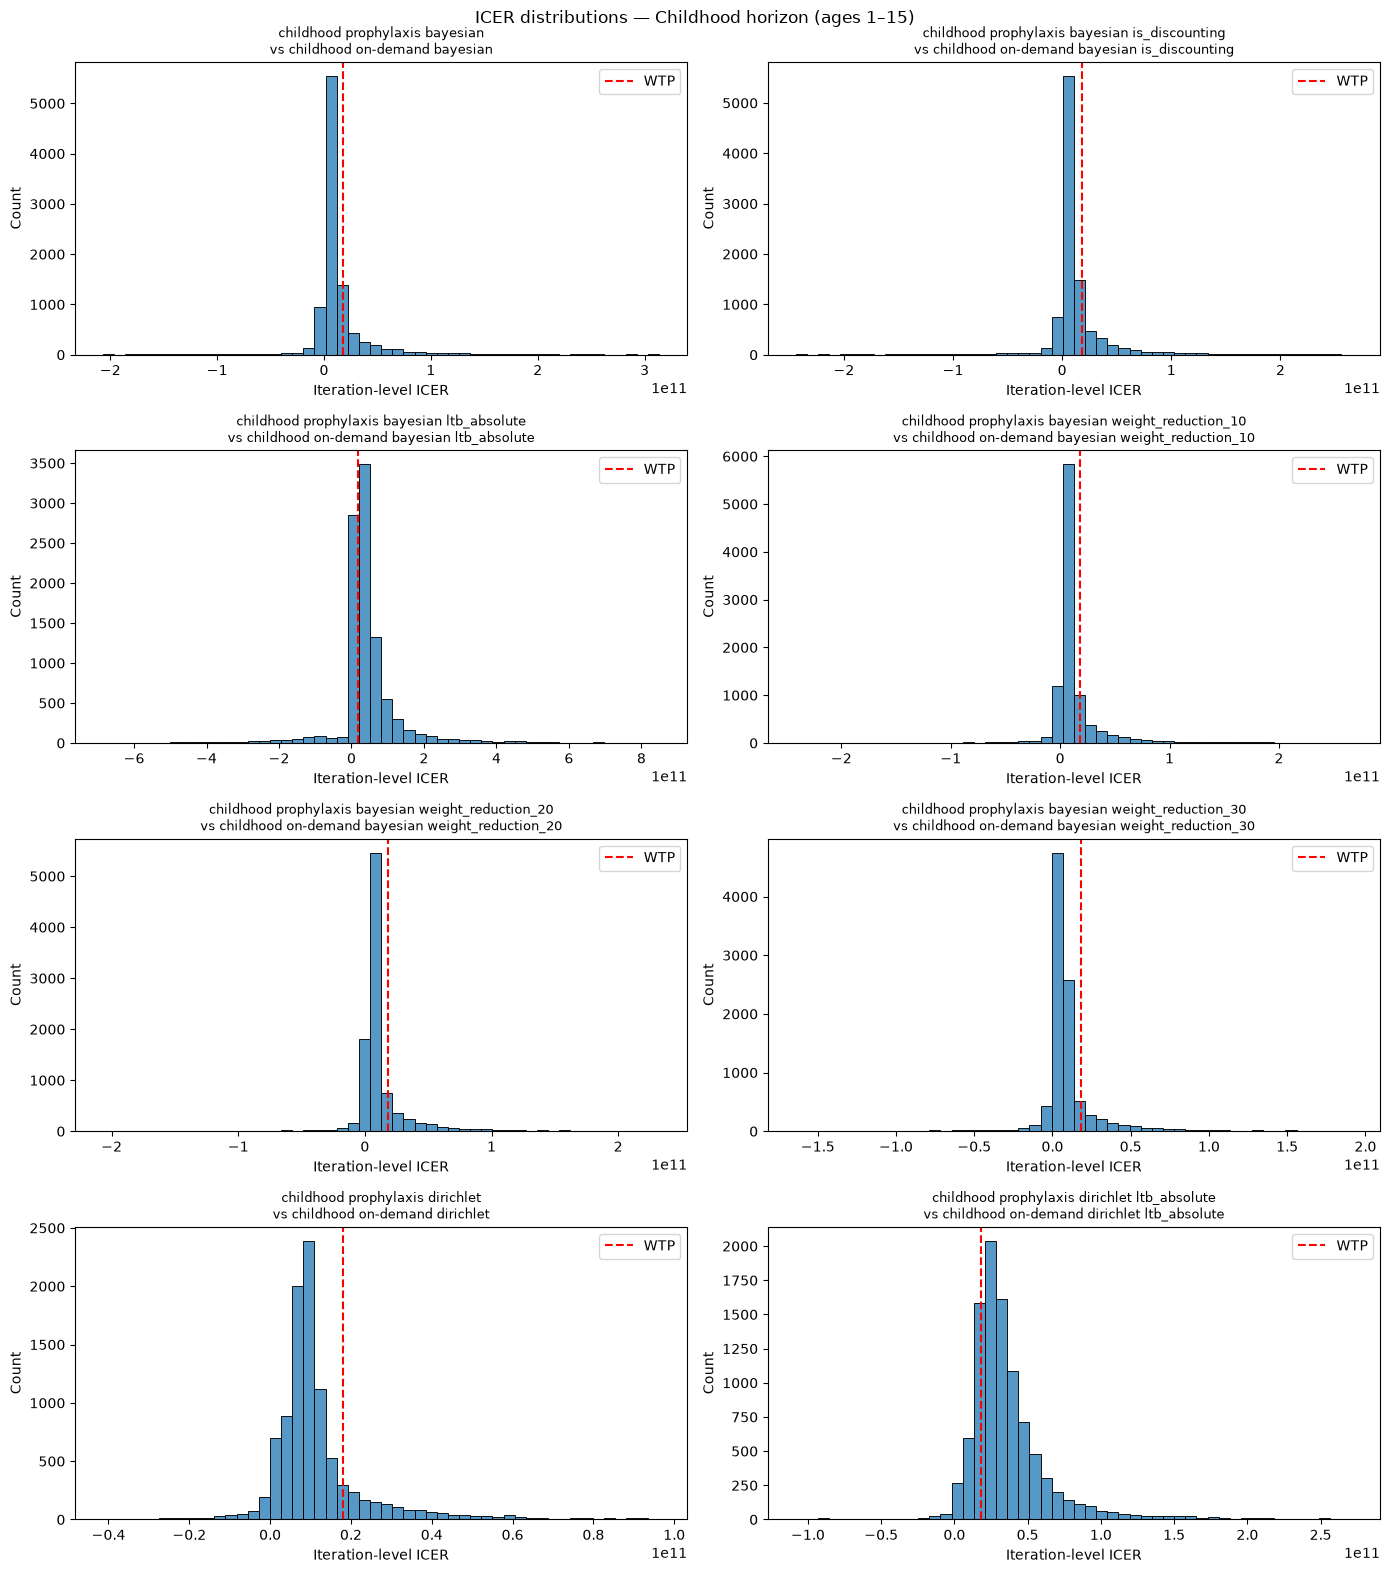

## Ceac

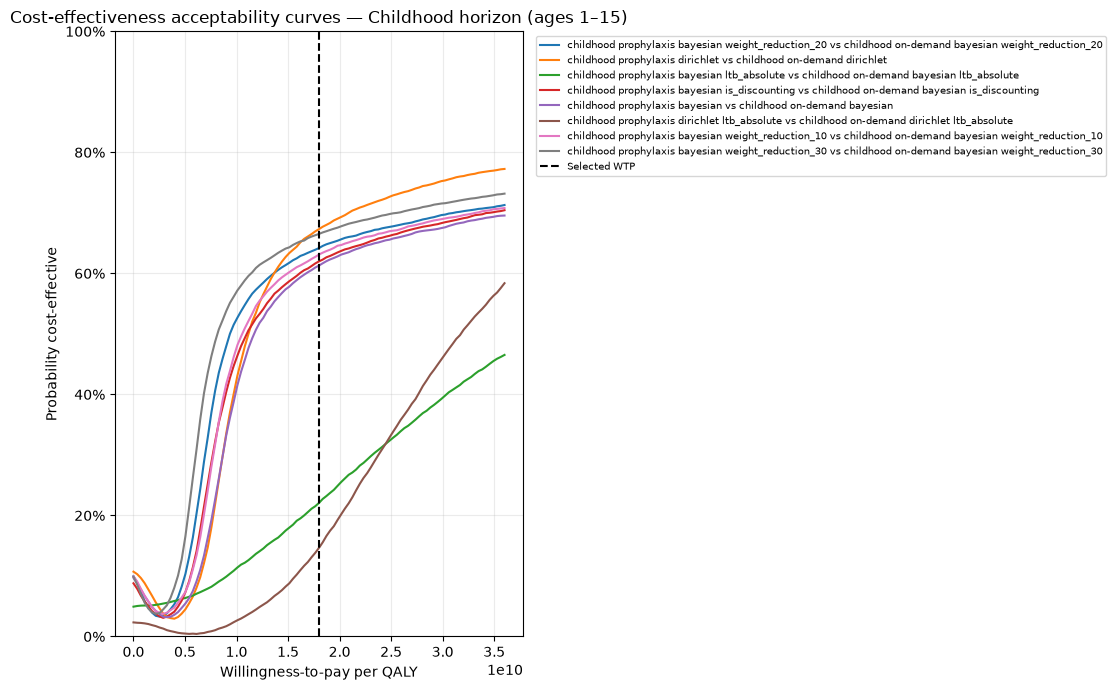

In [3]:
figures = report.figures()
saved_figures = report.save_figures(figures)

for title, figure in figures.items():
    display(Markdown(f"## {title.replace('_', ' ').title()}"))
    display(figure)
    plt.close(figure)


In [4]:
display(Markdown("## Saved figure files"))
for name, path in saved_figures.items():
    print(f"{name}: {path}")


## Saved figure files

abr_distribution: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\childhood_age_1_15\abr_distribution.png
survival_curve: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\childhood_age_1_15\survival_curve.png
health_state_distribution: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\childhood_age_1_15\health_state_distribution.png
qaly_distribution: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\childhood_age_1_15\qaly_distribution.png
cost_distribution: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\childhood_age_1_15\cost_distribution.png
joint_cost_qaly: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\childhood_age_1_15\joint_cost_qaly.png
cost_effectiveness_planes: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\childho